## NYC TLC Taxi Trip Data

Data is primarily from:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Data source: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page), 
via [NYC Open Data](https://opendata.cityofnewyork.us/).  
© City of New York. Data made available under the NYC Open Data Terms of Use.



In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from jfk_taxis import make_choropleth, load_config, create_save_listed_adjusted_choropleths, multiplot_choropleths
import numpy as np

In [ ]:
# Load config and project root
config, PROJECT_ROOT = load_config()

# Location of data
DATA_DIR_RAW = PROJECT_ROOT / config["data"]["data_path"] / config["data"]["raw_path"]

# Location to save reports
DATA_DIR_MAPS = PROJECT_ROOT / config["data"]["reports_path"] / config["data"]["maps_path"]

In [ ]:
# Load Januarary 2025 
df = pd.read_parquet(DATA_DIR_RAW / "yellow_tripdata_2025-01.parquet")

# We use Jan 2025 here as we are more interesting in exploring the taxi zones themselves for now 
# If you would like you can use any month/year, with the exception of 2009-2010 as they have lat long rather than a PULocationID column


In [ ]:
times = df["tpep_pickup_datetime"] 

NameError: name 'df' is not defined

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


You can find a full data dictionary here: [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) under the Yellow Trips Data Dictionary. As we won't be using all the columns I wil just point out the useful ones here.

tpep_pickup_datetime: the datetime for the taxi pickup

tpep_dropoff_datetime: the datetime for the taxi drop off

passenger_count: the number of passengers

trip_distance: trip distance in miles recorded by the taximeter

PULocationID: the location id of the taxi zone that the trip pick up occured in (useful when we make choropleths later)

DOLocationID: the location id of the taxi zone that the trip drop off occured in

total_amount: the total for the trip charged for passangers (there are lots of different price stats but we won't use them in this project, this is the most useful one to get an idea of the cost of a trip)


In [5]:
# Load taxi_zone_lookup.csv, this contains a mapping between the location id, the borough, zone and service zone
taxi_zone_lookup = pd.read_csv(DATA_DIR_RAW / "taxi_zone_lookup.csv")

In [6]:
taxi_zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


This csv allows us to match the LocationID from POLocationID/DOLocationID to an actual taxi zone, e.g. Newark Airport or JFK Airport. 

There are other columns like Borough that tell us which NYC Borough we are located in, as well as service_zone which seems to be split between: Yellow Zone, Boro Zone, EWR and Airports. It's worth noting that NYC also has Green Taxis which were introudced in 2013 to help with taxi service in the boroughs. 

In [7]:
# We now load the geospatial data for the taxi zones
taxi_zones_shape = gpd.read_file(DATA_DIR_RAW / "taxi_zones.shp")

In [8]:
taxi_zones_shape.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [9]:
type(taxi_zone_lookup)

pandas.core.frame.DataFrame

The above is our geospatial data for the taxi zones. 

The geometry column contains the polygons (and multipolygons) for the zones themselves. 

The other key column for us is the LocationID. This allows us to match the trips in df to their respective taxi zone for the choropleth. 

This data frame also contain the zone and borough from the taxi_zone_lookup csv, which we will use when creating the tool tips for the choropleth. However we still need to use taxi_zone_lookup to get the service_zone.


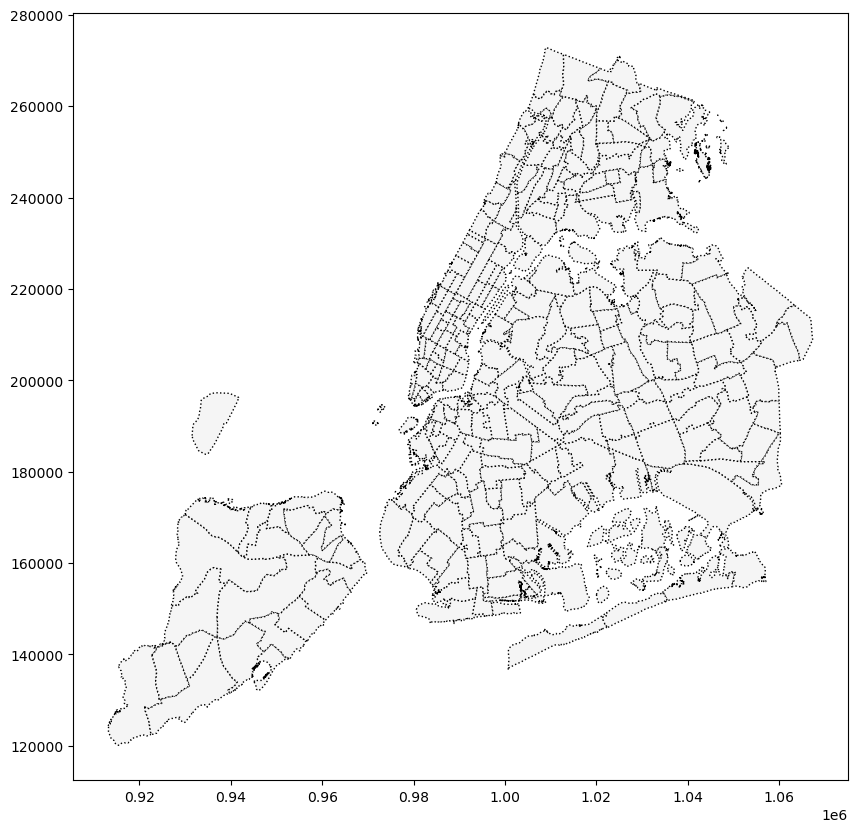

In [10]:
# We create a plot of the taxi zones from the geometry column
taxi_zones_shape.plot(figsize = (10,10), color = "whitesmoke", linestyle = ":", edgecolor = "black")
plt.show()

In [11]:
# We can also add these taxi zones to a folium map, this will be outputted to the reports/maps directory

# Reproject to EPSG 4326 for folium
taxi_zones_folium = taxi_zones_shape.to_crs(epsg = 4326)

# Make base map centered on NYC
m = folium.Map(location = [40.7128, -74.0060], zoom_start = 11)

# Add polygons
folium.GeoJson(
    taxi_zones_folium,
    tooltip = folium.GeoJsonTooltip(fields = ["zone", "borough"])
).add_to(m)
m.save(DATA_DIR_MAPS / "taxi_zones.html")

We now create two choropleths for the taxi zones, one for pick ups and the other for drop offs. The choropleths will show a breakdown of the number of taxi pickups (resp. drop offs) for each taxi zone. Again these will be saved to reports/maps if you would like to view them in your browser. 

There is a tooltip showing the following:
Zone: The name of the taxi zone
Borough: Which borough the taxi zone is located inside
Trips: Number of taxi trips in this zone
Service Zone: This appears to be a simple description of the type of zone, so Airport for JFK, Boro Zone in the Boroughs (although there is no official data dictionary for this that I could find)
LocationID: This is the location id for the taxi zone which you can see in df as either PULocationID (pickup location ID) or DOLocationID (drop off location ID)

We will use a helper function from jfk_taxis called make_choropleth, you can view jfk_taxis in src/jfk_taxis. Make choropleth is locating inside eda_helpers.py.
 

In [ ]:
# Create pick up Choropleth
m_1 = make_choropleth(df, "PULocationID", taxi_zones_folium, taxi_zone_lookup, "", None, False)

# Export to HTML file
m_1.save(DATA_DIR_MAPS / "PULocationID_count_by_zone_2025_01.html")

# Create drop off Choropleth
m_2 = make_choropleth(df, "DOLocationID", taxi_zones_folium, taxi_zone_lookup, "", None, False)

# Export to HTML file
m_2.save(DATA_DIR_MAPS / "DOLocationID_count_by_zone_2025_01.html")

There are a couple intersting things to observe, firstly most of the drop offs and pickups occur in either Manhattan or JFK Airport. This is in line with what we would expect and partly informs our later decision to focus on JFK Airport itself. The other interesting thing is just how low the taxi trip counts are in the other boroughs. This is likely due to a combination of both Uber and other for hire vehicle service providers as well as NYCs own introduction of green taxis. However it would be interesting to look at earlier years like 2011 to see how yellow taxi use varies in the outer boroughs of NYC. 

Before we move our analysis to exclusively JFK Airport we will make some further choropleths for various other months/years just to get an overal idea of how taxi use is distrbiuted throughout NYC (and mostly just to have a look out of curiosity).  

In [ ]:
# Years and months to investigate
years = [2011, 2016, 2020, 2025]

months = ["01", "03", "06", "08", "12"]

# To make the comparison easier we are going to fix the choropleth scale, we note that the largest values are just under 700,000 so we will go up in 100,000 trips
# for about 7 bins
scale = np.arange(0, 700001, 100000).tolist() 

# Extra string to add to the map legend
extra = ""

# Ignore for now but the following will become useful later
# Boroughs to drop from the data
drop_boroughs = []

# Location IDs to drop from the data
drop_ids = []

# File suffix to add to the saved file names
file_suffix = "full_scale"

# Bool to determine if we should drop the rows that are over the scale
drop_over_scale = False


In [ ]:
# This function creates and saves the adjusted choropleths for the specified years and months, you can find them in reports/maps with the file_suffix provided above
create_save_listed_adjusted_choropleths(taxi_zones_folium, taxi_zone_lookup, extra, scale, years, months, drop_boroughs, drop_ids, file_suffix, drop_over_scale)

There are a few intersting things in the above maps. In the boroughs we can see some considerable changes in taxi use, for example Forest Hill Queens, LocationID 95 has 10,411 pick up trips in Jan 2011 and only 1,428 in Jan 2025. Which marks a ten fold decrease, likely explanations would be the introduction of NYCs green taxis in 2013 to help with demand in the boroughs. Which does seem to match the data as in Jan 2016 (3 years after the introduction of green taxis) the number of trips in Forest Hills is only 2,050, whilst its drop off rate is still high at 14,106 trips. Although we can't be certain green taxis are entirely responsible for this as there could be other factors like Ubers introduction to NYC in May 2011. 

If we wish to further investigate this it would be worth removing Manhattan and the Airports like JFK and LaGuardia from the choropleth. The reason being that these areas have sometimes 100 times more taxi trips than even a reasonably busy borough. For example in 2016 drop offs for March you can see that the lowest colour on the scale counts from 2 to 76,839 trips, which means we can't visually get a good sense of taxi use within the boroughs themselves. We will investigate this in the cell below.

However it is also worth noting that overall yellow taxi use seems to have considerably fallen over the years. You can see this visually when comparing pick ups in Jan 2011 and Jan 2025. Notice that in 2011 the deepest blue starts at 422,115 ending at 506,537 and in 2025 it starts at 141,648 ending at 169,997. Then when you look in just Manhattan you can see a lot more of this deepest blue in 2011 than in 2025, and checking the value using the tooltip will show you there seems to be a considerable drop in yellow taxi usage in Manhattan of between 3-4 fold in a lot of zones. This trend will be shown for JFK Airport later when we plot the daily taxi count during our data processing.

The final key feature worth noting is that both JFK Airport and Manhattan are where a majoirty of trips go to and from as is expected. With some other regions like LaGuardia Airport also having a considerable number of trips. 


Rewrite the above

In [ ]:
# Years and months to investigate
years = [2011, 2016, 2020, 2025]

months = ["01", "03", "06", "08", "12"]

# Again for easier comparsion we will fix the scale, from investiagtion the maximum trip counts that occur are around just under 80,000 so we will create 8 bins going up in 10,000s
scale = np.arange(0, 80001, 10000).tolist()

# Extra string to add to the map legend
extra = " no Manhattan"

# We need to drop Manhattan from both the dataframes and the geo spatial data, we specifiy this using drop_boroughs 

# From additional exploration we will also need to drop JFK Airport and LaGuardia Airport we can't do this by borough so we have a sepearte function to drop by location ID
# JFK has id 132, LaGuardia has id 138. We pass these to drop_ids.

# We also observe that location id 264 which corresponds to unkown also has a lot of trips that distorts the scale, for example in 2011 it has 309,226 trips.
# So we will remove it as well

# We further observre that location id 265 can also cause high trip counts, e.g. 118,772 in 03 2011 for pick ups. 265 corresponds to outside NYC so we can safely drop it.


# Boroughs to drop from the data
drop_boroughs = ["Manhattan"]

# Location IDs to drop from the data
drop_ids = [132, 138, 264, 265]

# File suffix to add to the saved file names
file_suffix = "no_manhattan"

# Bool to determine if we should drop the rows that are over the scale
drop_over_scale = False

In [ ]:
# Create Choropleths
create_save_listed_adjusted_choropleths(taxi_zones_folium, taxi_zone_lookup, extra, scale, years, months, drop_boroughs, drop_ids, file_suffix, drop_over_scale)

Looking at January from across 2011, 2016, 2020 to 2025 we see that yellow taxi use in the boroughs has dropped significantly outside Manhattan. You can see this just by comparing the scale from 2011 to 2025, the top end of the 2011 scale is 38,022 to 45,625 for pick ups whereas in 2025 it is only 8,249 to 9,889. 

A majority of this decrease is in zones like Astoria and Sunnyside Queens as well as Greenpoint, Willamsburg and Park Slope Brookyln. Interestingly there is actually a slight reversal in some of the zones more on the outskirts of NYC. For example in Jan 2001 there were 769 pickups in South Ozone Park, Queens. Whereas in Jan 2025 there were 2,291 pickups in South Ozone Park. So it appears that Green Taxis and services like Uber have had the most effect in the more Northern areas of Queens and Brookyln cloest to Manhattan but potentially outside of this yellow taxi use has actually increased. 

We take a look at Jan 2016 to get a better idea as this is 3 years after the introduction of Green Taxis which are targeted specically in these boroughs. The drop off choropleth looks roughly similar to that in 2011 with maybe slightly fewer yellow taxis but still high numbers in the zones outlined from Queens and Brookyln in the above paragraph. However 


Rewrite the above

Our final set of choropleths will look at the zones outside of the cluster in Queens and Brookyln with around 10,000+ trips. You can see by 2025 there are essentially no zones with 10,000+ trips so we will create a new scale going only up to 20,000 and anything over that labelled in a 20,000 + category

In [ ]:
# Years and months to investigate
years = [2011, 2016, 2020, 2025]

months = ["01", "03", "06", "08", "12"]

# We go up to only 2500 to see the contrast in lower trip counts. However to avoid having to remove too many zones we will add 80,000 on the end of the scale.
scale = np.arange(0, 20001, 2500).tolist() 
scale.append(80000)

# Extra string to add to the map legend
extra = " no Manhattan"

# Boroughs to drop from the data
drop_boroughs = ["Manhattan"]

# Location IDs to drop from the data
drop_ids = [132, 138, 264, 265]

# File suffix to add to the saved file names
file_suffix = "small_scale"

# Bool to determine if we should drop the rows that are over the scale
drop_over_scale = False

In [ ]:
# Create Choropleths
create_save_listed_adjusted_choropleths(taxi_zones_folium, taxi_zone_lookup, extra, scale, years, months, drop_boroughs, drop_ids, file_suffix, drop_over_scale)

If you look at say drop offs in Jan it appears at first glance that although there has been an overall global decrease in taxi counts particualarly in the central zones close to Manhattan, there doesn't seem to have been that dramatic of a change in the spread of taxi drop offs within the boroughs. 


Comments about pick ups etc etc


To make for a nice visual comparison we will now plot the choropleths for Jan for 2011, 2016, 2020, 2025 all on one plot for the three different scales (full scale, no Manhattan, small_scale). Just to make it easier to compare rather than having to look through several folium maps.

In [10]:
# Define constants for multiplot_choropleths function
years = [2011, 2016, 2020, 2025]
months = ["01"]

# We define the three scales here:
scales = [
    [0, 700000], # Full scale
    [0, 80000],  # No Manhattan
    [0, 20000]   # Small scale no Manhattan
]

# Geo data to pass
geo_data = taxi_zones_shape.copy()

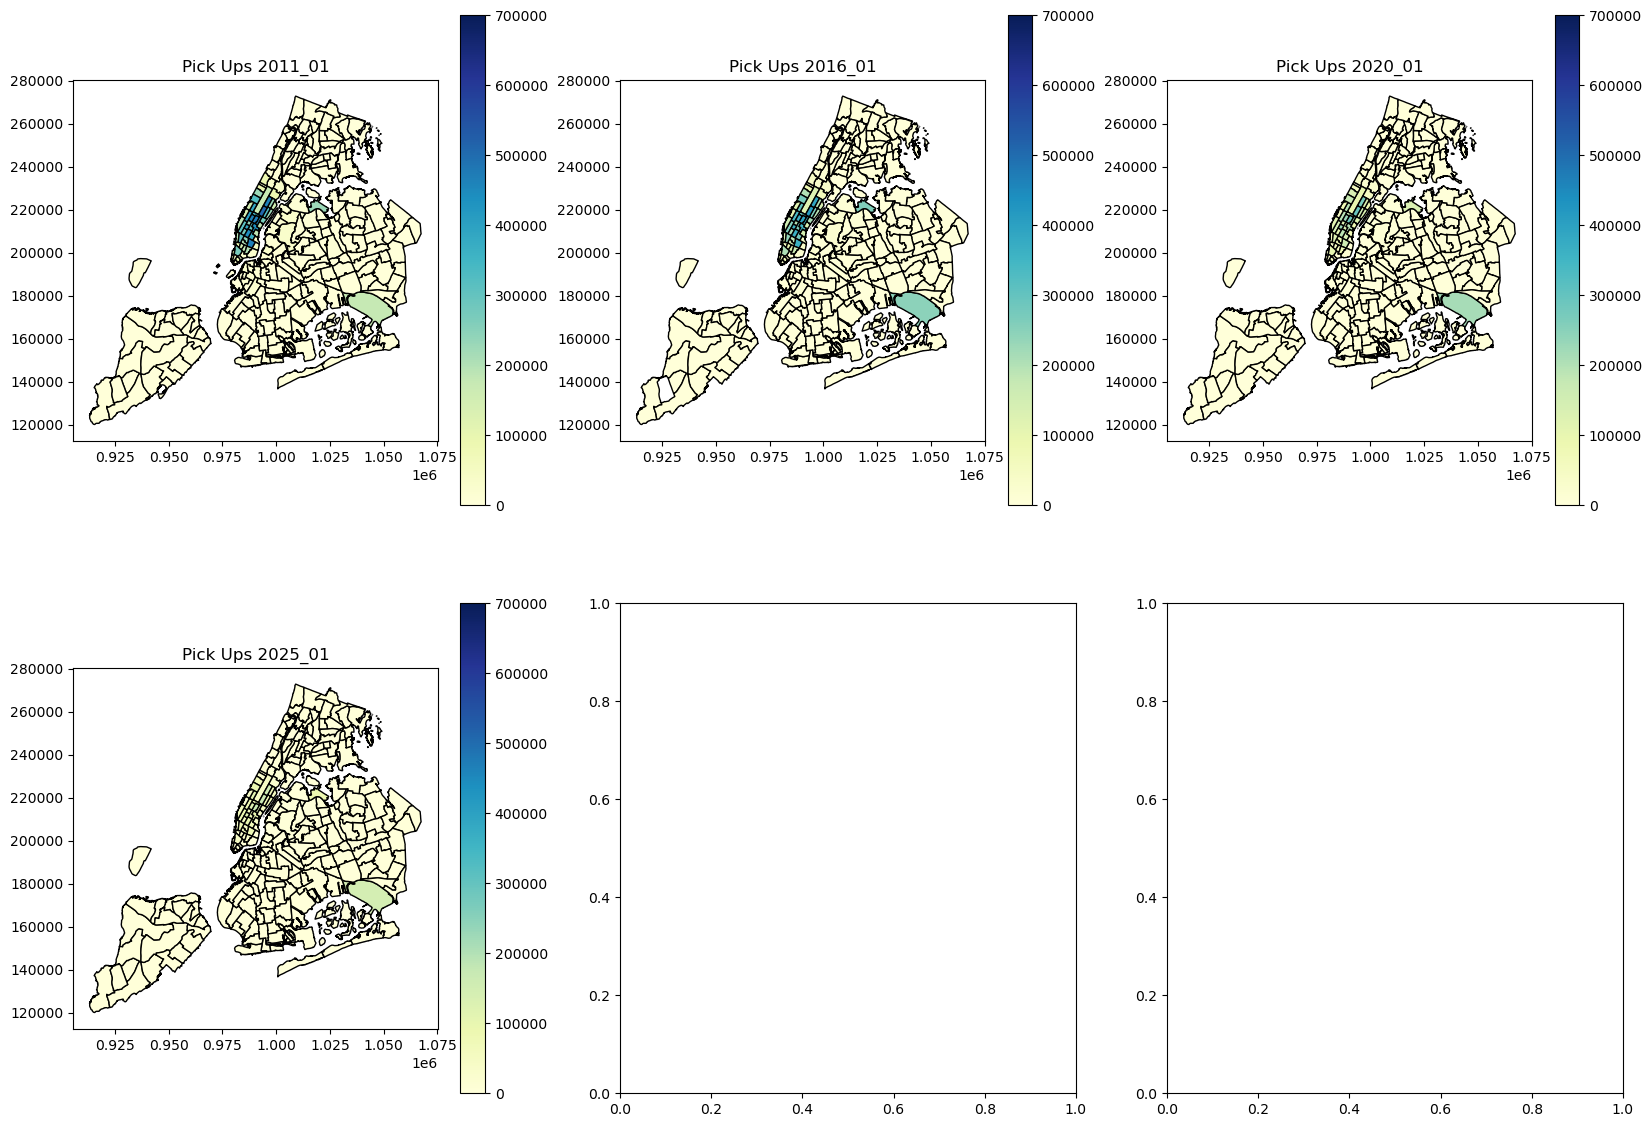

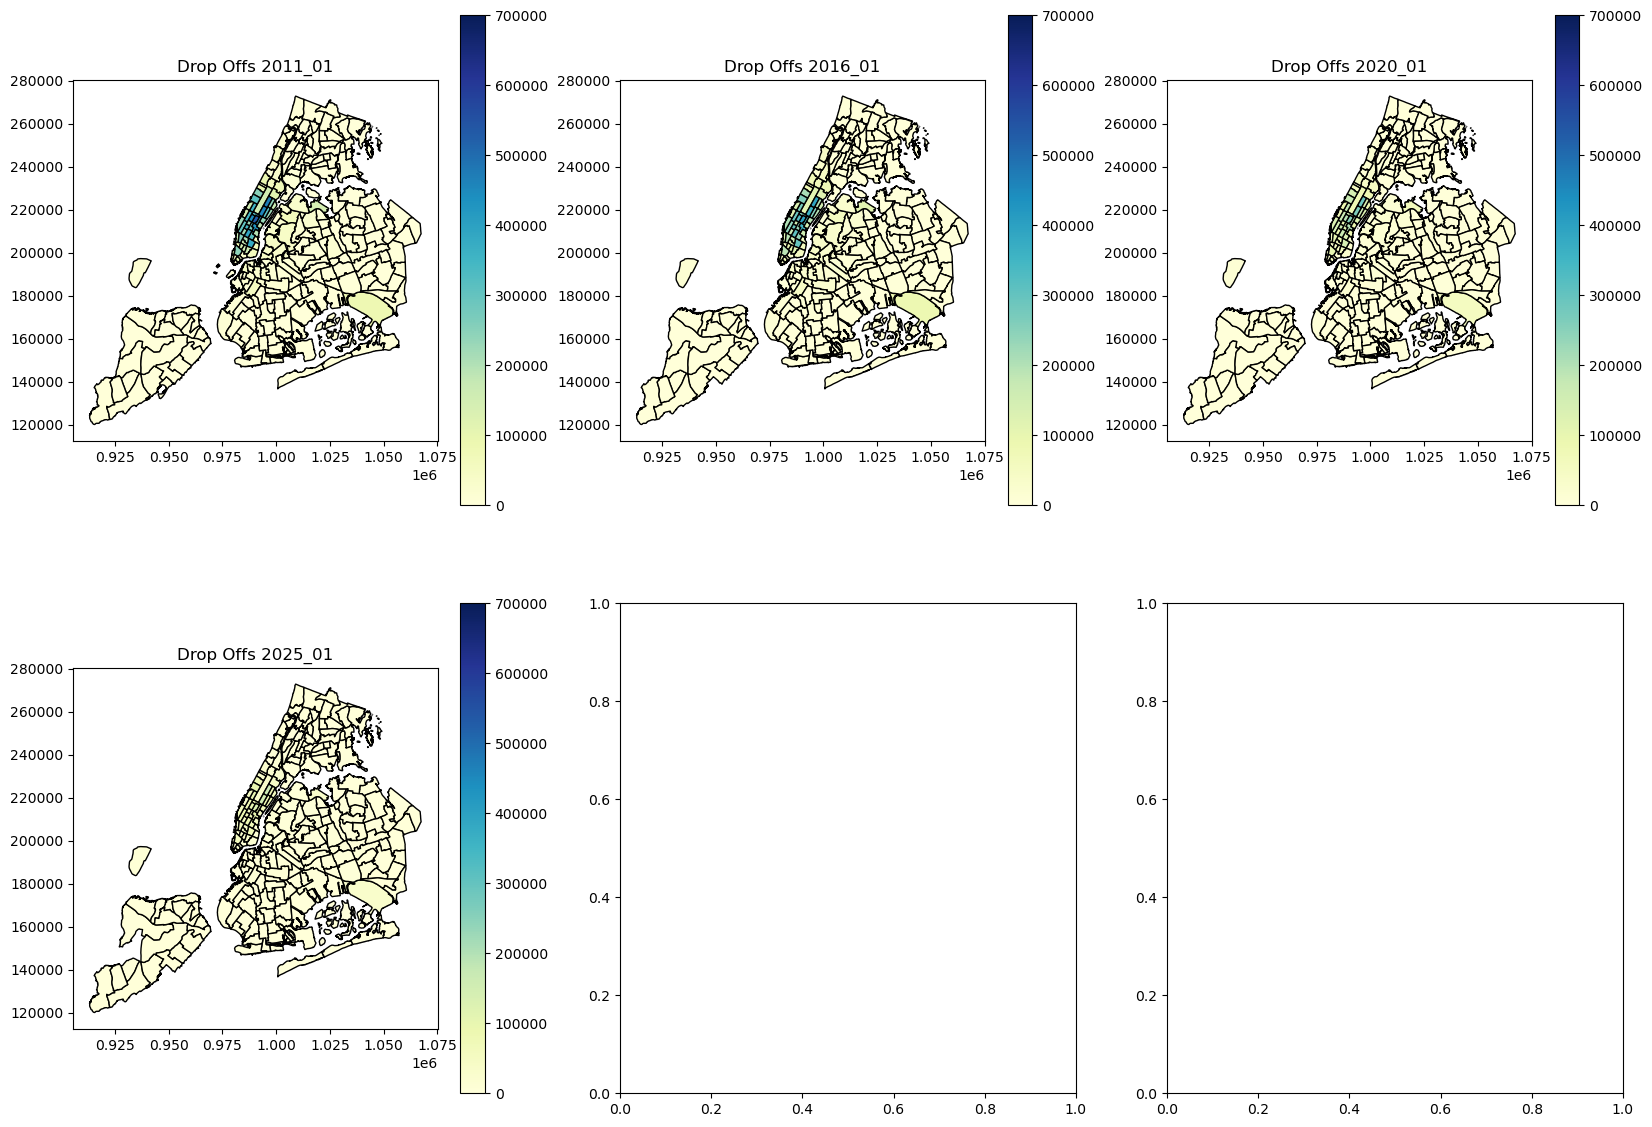

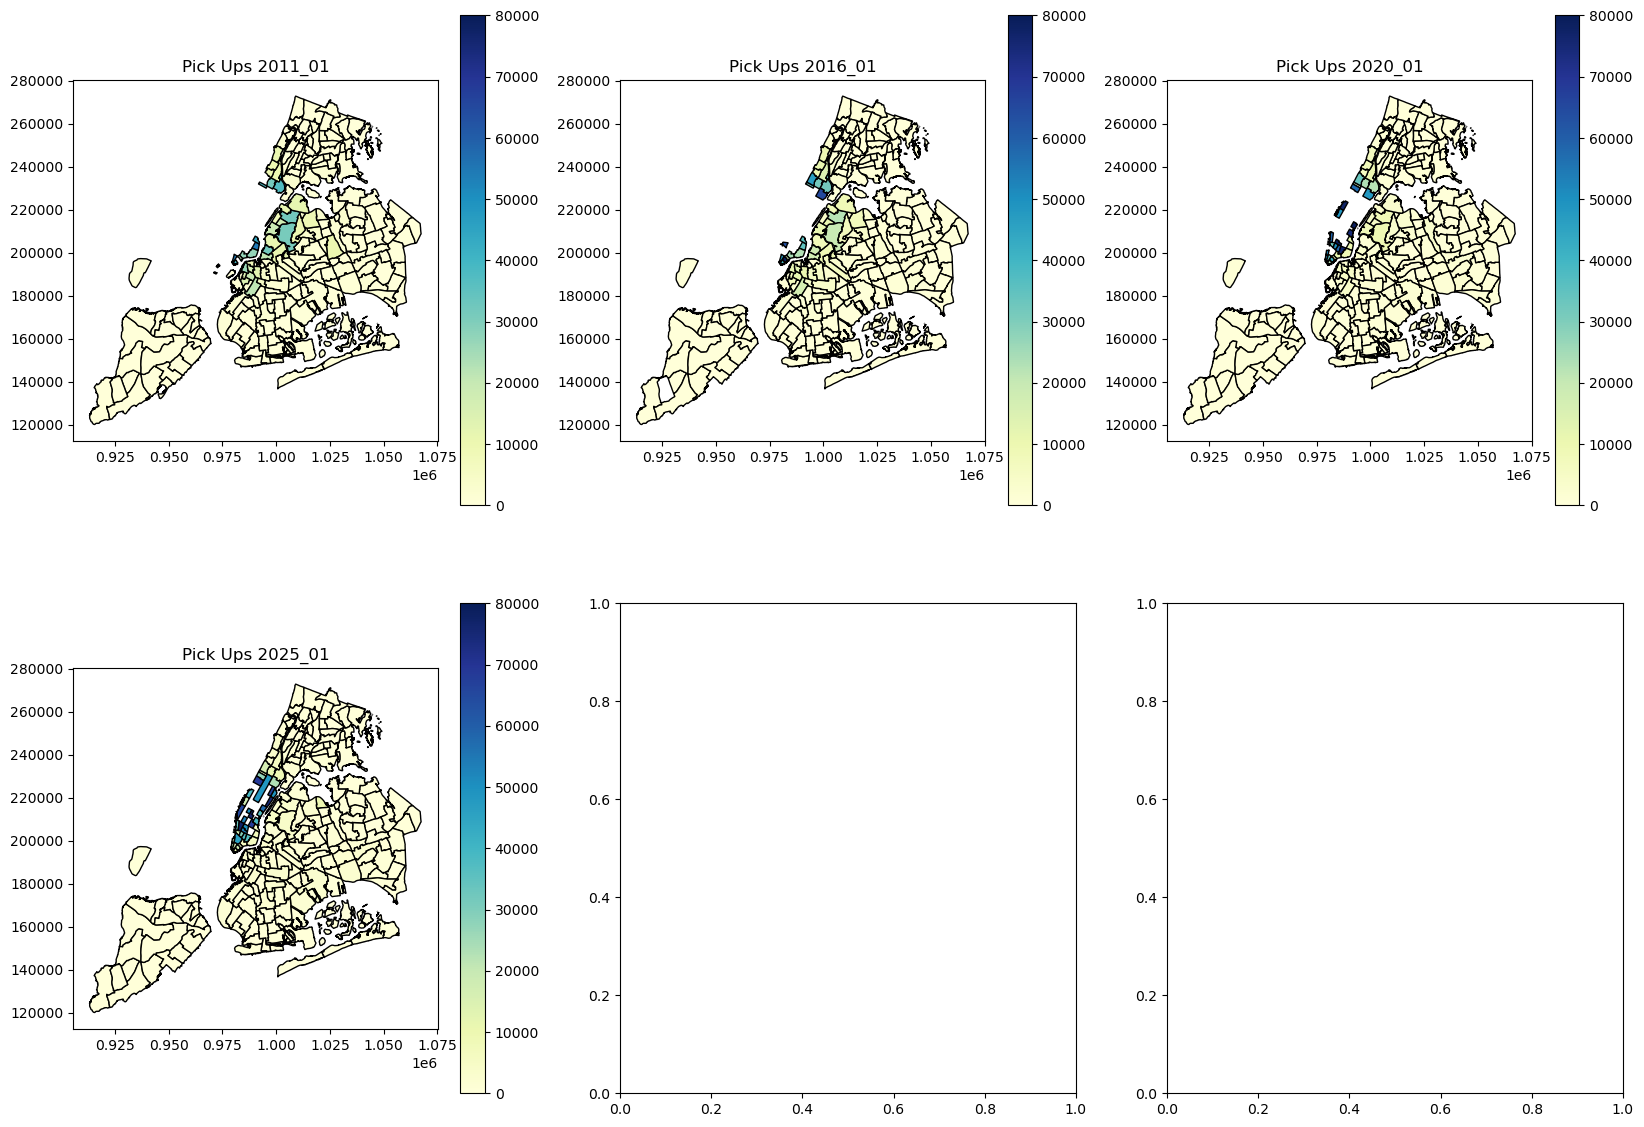

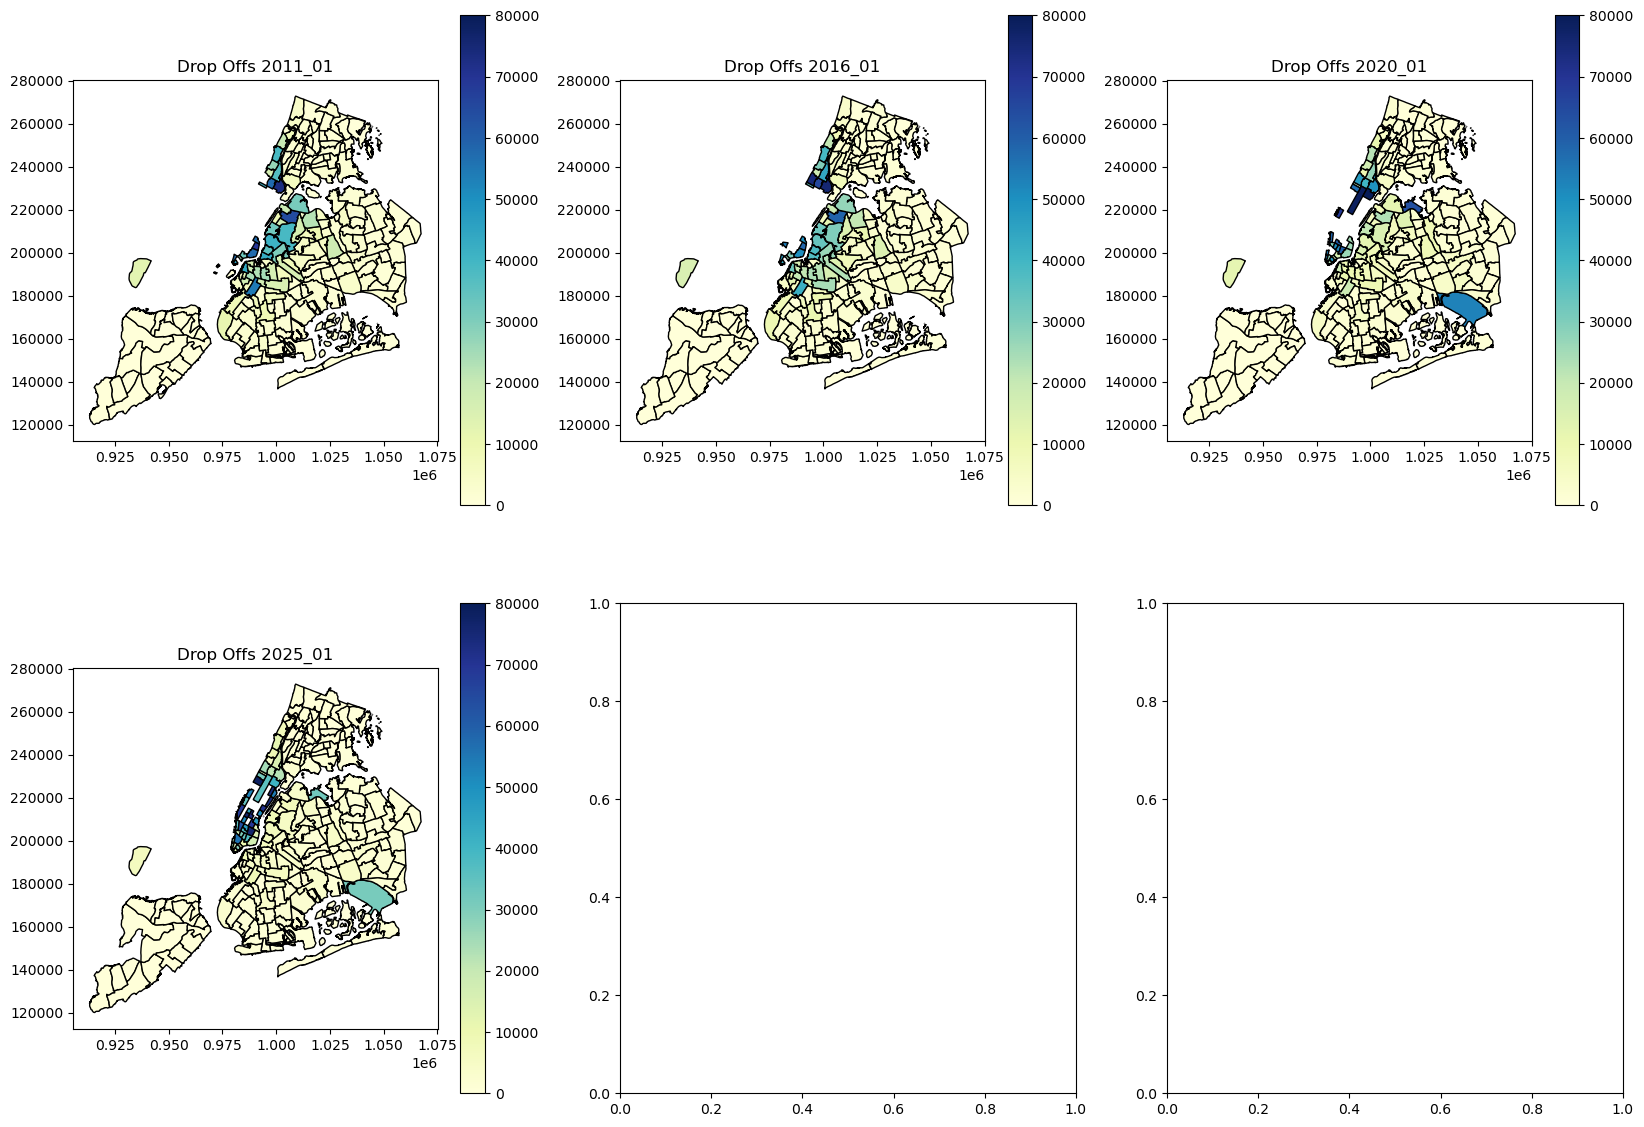

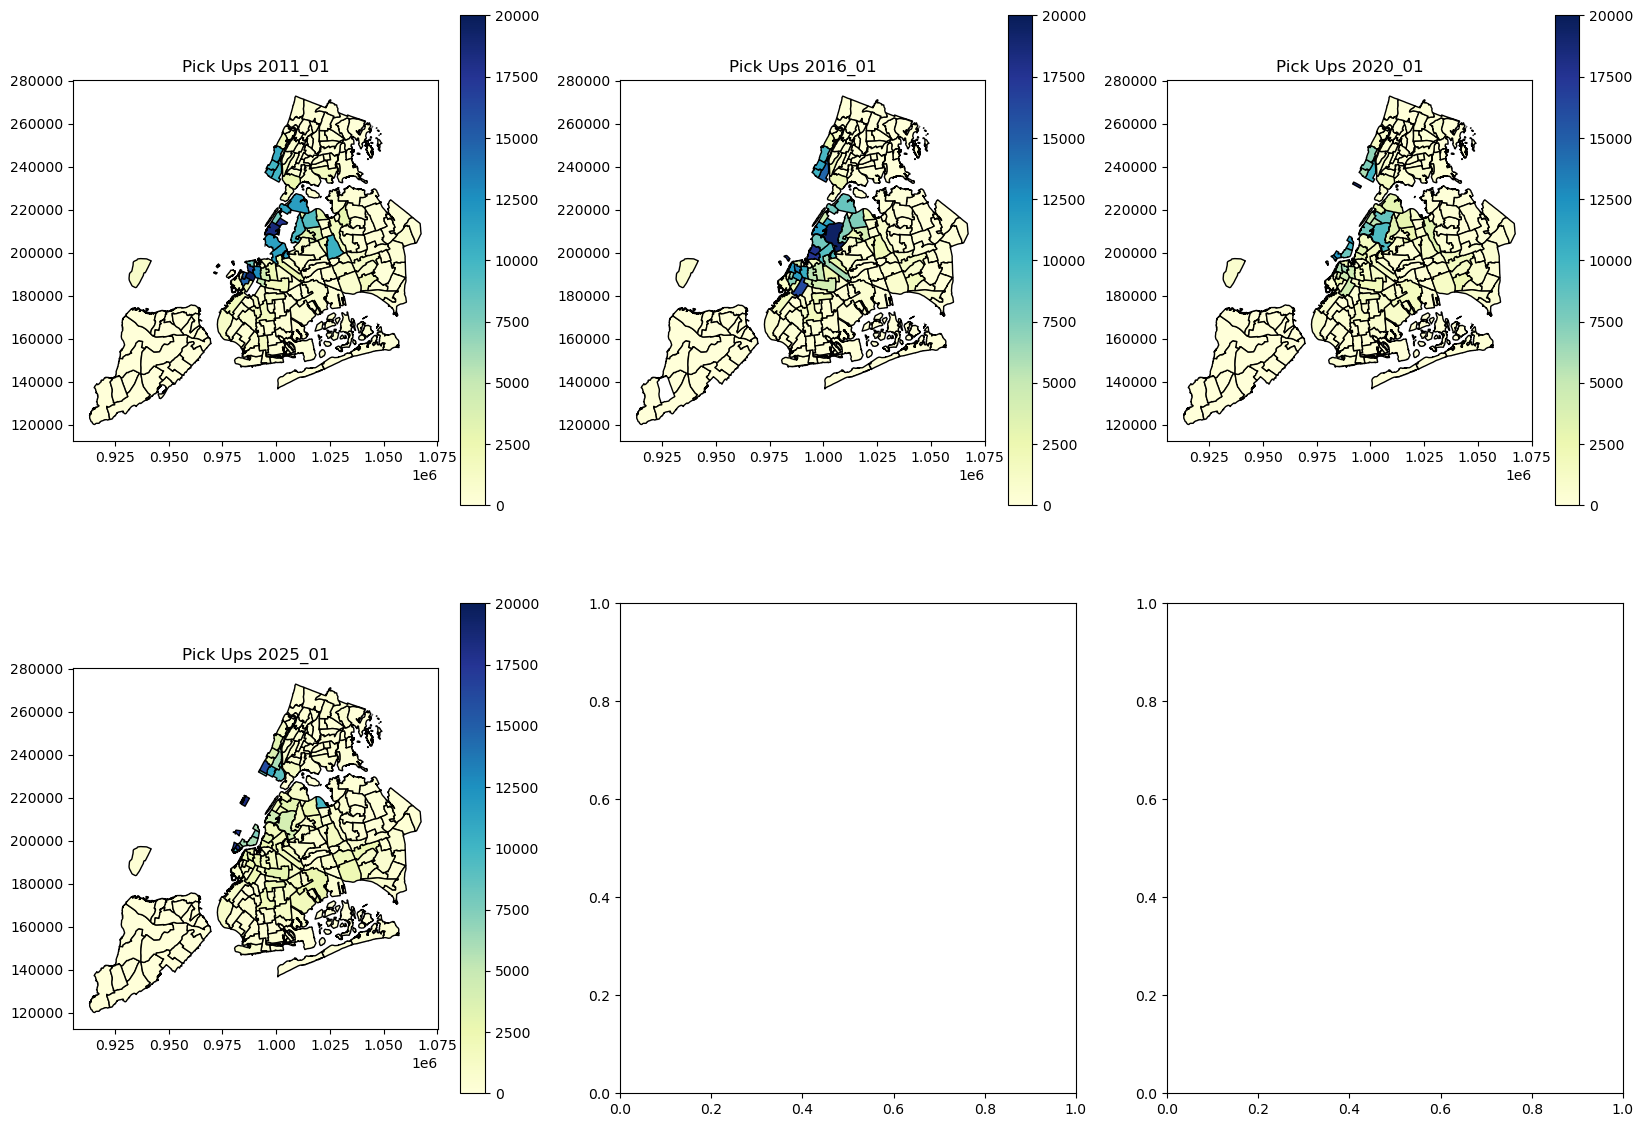

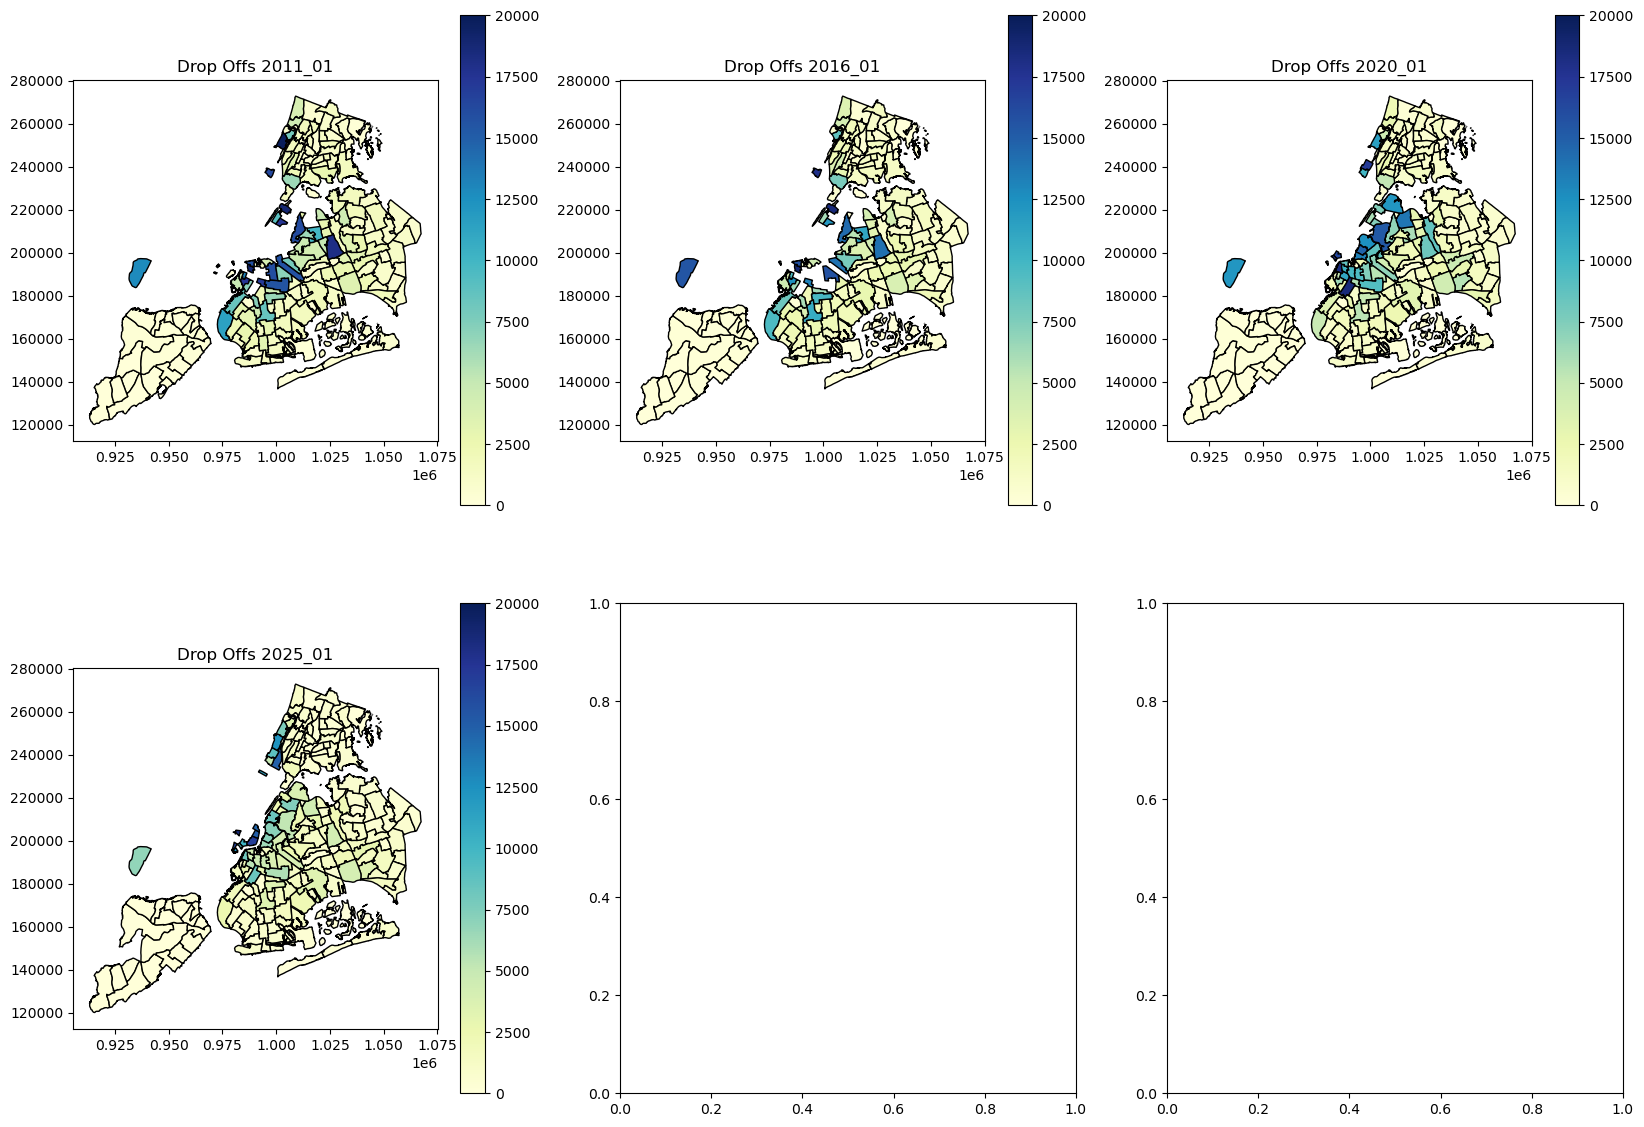

In [11]:
# Loop through scales and create the multiplot choropleths
for scale in scales:
    multiplot_choropleths(geo_data, scale, years, months)

Comment on these chorpleths etc etc